# July 6th Training Run Analysis: Statistical Comparison

3 runs of each condition with early stopping (patience=3):
- **No-MADIS**: radar only, MLP head
- **MADIS Full**: 6 surface weather features fused with CNN
- **MADIS Top-3**: pressure, wind_gust, pressure_anomaly_24h only

All runs: train 2013–2020, val 2021–2022, batch size 64, start_filters=48.

Primary question: **Is the difference in val_AUC between conditions statistically significant, or explained by random seed variance?**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

BASE = '../results/run_july_6th/results'

def load_runs(pattern_list):
    runs = []
    for path in pattern_list:
        full = f'{BASE}/{path}'
        if os.path.exists(full):
            df = pd.read_csv(full)
            df.index = range(1, len(df) + 1)
            runs.append(df)
        else:
            print(f'  WARNING: missing {path}')
    return runs

madis_runs    = load_runs([f'madis_hybrid_run{i}_history.csv' for i in range(1, 4)])
no_madis_runs = load_runs([f'no_madis_run{i}_history.csv'     for i in range(1, 4)])
top3_runs     = load_runs([f'madis_top3_run{i}_history.csv'   for i in range(1, 4)])

print(f'Loaded — MADIS Hybrid: {len(madis_runs)} runs, No-MADIS: {len(no_madis_runs)} runs, MADIS Top-3: {len(top3_runs)} runs')

madis_best    = [df['val_AUC'].max() for df in madis_runs]
no_madis_best = [df['val_AUC'].max() for df in no_madis_runs]
top3_best     = [df['val_AUC'].max() for df in top3_runs]

print('\nBest val_AUC per run:')
print(f'  No-MADIS:     {[round(x, 4) for x in no_madis_best]}')
print(f'  MADIS Hybrid: {[round(x, 4) for x in madis_best]}')
print(f'  MADIS Top-3:  {[round(x, 4) for x in top3_best]}')

Loaded — MADIS Hybrid: 3 runs, No-MADIS: 3 runs, MADIS Top-3: 3 runs

Best val_AUC per run:
  No-MADIS:     [0.8901, 0.8895, 0.8901]
  MADIS Hybrid: [0.8966, 0.8972, 0.892]
  MADIS Top-3:  [0.8939, 0.8929, 0.8988]


## Summary Statistics

In [10]:
summary = pd.DataFrame({
    'No-MADIS':      no_madis_best,
    'MADIS Hybrid':  madis_best,
    'MADIS Top-3':   top3_best,
})

stats_table = summary.agg(['mean', 'std', 'min', 'max'])
n = len(madis_best)
stats_table.loc['95% CI low']  = stats_table.loc['mean'] - 1.96 * stats_table.loc['std'] / np.sqrt(n)
stats_table.loc['95% CI high'] = stats_table.loc['mean'] + 1.96 * stats_table.loc['std'] / np.sqrt(n)
print(stats_table.round(4))

             No-MADIS  MADIS Hybrid  MADIS Top-3
mean           0.8899        0.8953       0.8952
std            0.0004        0.0028       0.0031
min            0.8895        0.8920       0.8929
max            0.8901        0.8972       0.8988
95% CI low     0.8895        0.8921       0.8917
95% CI high    0.8903        0.8985       0.8988


## Statistical Significance Testing

Two tests:
- **Welch's t-test**: assumes normality, good for small samples with potentially unequal variance
- **Mann-Whitney U**: non-parametric, no normality assumption (safer with n=3)

Note: with only n=3 runs per condition these tests have very low power — a real effect of ~0.003 AUC may not reach significance.

In [11]:
comparisons = [
    ('MADIS Hybrid vs No-MADIS',   madis_best,  no_madis_best),
    ('MADIS Top-3 vs No-MADIS',    top3_best,   no_madis_best),
    ('MADIS Hybrid vs MADIS Top-3', madis_best,  top3_best),
]

print(f'{"Comparison":<32} {"t-test p":>10} {"MW-U p":>10} {"Mean diff":>12} {"Significant?":>14}')
print('-' * 82)
for label, a, b in comparisons:
    if len(a) < 2 or len(b) < 2:
        print(f'{label:<32} {"N/A (insufficient runs)":>48}')
        continue
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    mean_diff   = np.mean(a) - np.mean(b)
    sig = 'YES' if t_p < 0.05 or u_p < 0.05 else 'no'
    print(f'{label:<32} {t_p:>10.4f} {u_p:>10.4f} {mean_diff:>+12.4f} {sig:>14}')

print('\np < 0.05 = statistically significant at 95% confidence')

Comparison                         t-test p     MW-U p    Mean diff   Significant?
----------------------------------------------------------------------------------
MADIS Hybrid vs No-MADIS             0.0785     0.0765      +0.0054             no
MADIS Top-3 vs No-MADIS              0.0977     0.0765      +0.0053             no
MADIS Hybrid vs MADIS Top-3          0.9785     1.0000      +0.0001             no

p < 0.05 = statistically significant at 95% confidence


## Distribution of Best Val AUC Across Runs

/var/folders/2k/0qh4r79d2wl0b4skmgc5p80c0000gr/T/ipykernel_45786/3623825786.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)


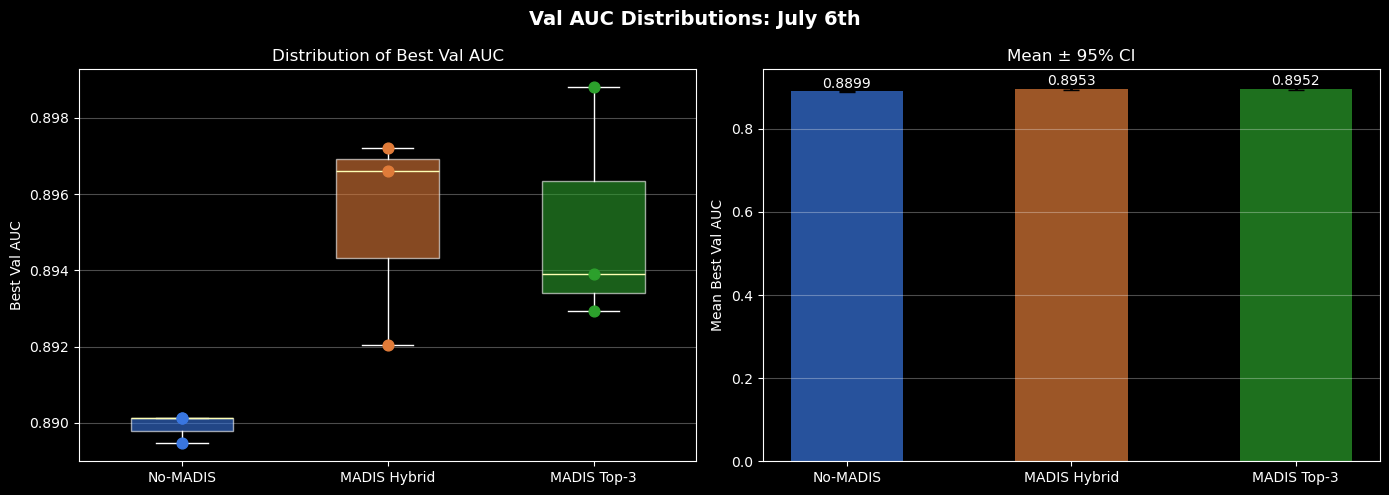

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data   = [no_madis_best, madis_best, top3_best]
labels = ['No-MADIS', 'MADIS Hybrid', 'MADIS Top-3']
colors = ['#3976e0', '#e07b39', '#2ca02c']

# Box plot
ax = axes[0]
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, (d, color) in enumerate(zip(data, colors), 1):
    ax.scatter([i] * len(d), d, color=color, zorder=5, s=60)

ax.set_ylabel('Best Val AUC')
ax.set_title(f'Distribution of Best Val AUC', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Mean ± 95% CI bar chart
ax = axes[1]
means = [np.mean(d) for d in data]
cis   = [1.96 * np.std(d) / np.sqrt(len(d)) if len(d) > 1 else 0 for d in data]

bars = ax.bar(labels, means, color=colors, alpha=0.7, width=0.5)
ax.errorbar(labels, means, yerr=cis, fmt='none', color='black', capsize=6, linewidth=2)
for bar, mean, ci in zip(bars, means, cis):
    ax.text(bar.get_x() + bar.get_width()/2, mean + ci + 0.0003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean Best Val AUC')
ax.set_title('Mean ± 95% CI', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Val AUC Distributions: July 6th', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/july6_auc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## AUC Curves — All Runs Overlaid

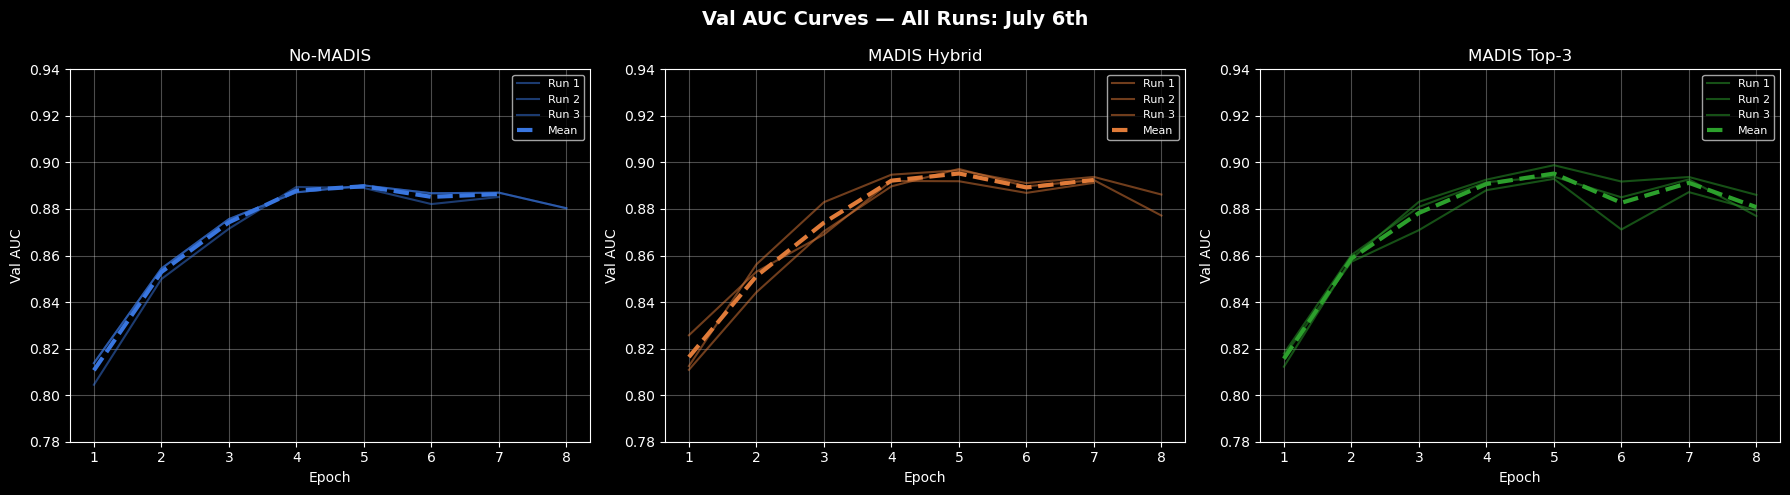

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

run_groups = [
    (no_madis_runs,  'No-MADIS',      '#3976e0'),
    (madis_runs,     'MADIS Hybrid',  '#e07b39'),
    (top3_runs,      'MADIS Top-3',   '#2ca02c'),
]

for ax, (runs, title, color) in zip(axes, run_groups):
    if not runs:
        ax.set_title(f'{title} — no data', fontsize=12)
        continue
    for i, df in enumerate(runs):
        ax.plot(df.index, df['val_AUC'], color=color, linewidth=1.5,
                alpha=0.5, label=f'Run {i+1}')
    # Mean curve (only meaningful if multiple runs)
    if len(runs) > 1:
        min_len = min(len(df) for df in runs)
        mean_curve = np.mean([df['val_AUC'].values[:min_len] for df in runs], axis=0)
        ax.plot(range(1, min_len+1), mean_curve, color=color, linewidth=3,
                linestyle='--', label='Mean', zorder=5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val AUC')
    ax.set_ylim(0.78, 0.94)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Val AUC Curves — All Runs: July 6th', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/july6_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head: Best Val Metrics at Best Epoch (Averaged Across Runs)

In [14]:
metric_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall']

def best_epoch_metrics(runs):
    rows = [df.loc[df['val_AUC'].idxmax(), metric_cols] for df in runs]
    df_all = pd.DataFrame(rows)
    return df_all.mean(), df_all.std()

no_madis_mean, no_madis_sd = best_epoch_metrics(no_madis_runs)
madis_mean,    madis_sd    = best_epoch_metrics(madis_runs)
top3_mean,     top3_sd     = best_epoch_metrics(top3_runs)

mean_df = pd.DataFrame({
    'No-MADIS (mean)':      no_madis_mean,
    'MADIS Hybrid (mean)':  madis_mean,
    'MADIS Top-3 (mean)':   top3_mean,
})
std_df = pd.DataFrame({
    'No-MADIS (std)':      no_madis_sd,
    'MADIS Hybrid (std)':  madis_sd,
    'MADIS Top-3 (std)':   top3_sd,
})

print('Mean metrics at best epoch:')
print(mean_df.round(4))
print('\nStd dev across runs:')
print(std_df.round(4))

Mean metrics at best epoch:
               No-MADIS (mean)  MADIS Hybrid (mean)  MADIS Top-3 (mean)
val_AUC                 0.8899               0.8953              0.8952
val_AUCPR               0.4807               0.4759              0.4919
val_F1                  0.4758               0.4725              0.4827
val_Precision           0.4833               0.4542              0.4616
val_Recall              0.4742               0.4957              0.5060

Std dev across runs:
               No-MADIS (std)  MADIS Hybrid (std)  MADIS Top-3 (std)
val_AUC                0.0004              0.0028             0.0031
val_AUCPR              0.0116              0.0146             0.0113
val_F1                 0.0078              0.0030             0.0068
val_Precision          0.0516              0.0337             0.0080
val_Recall             0.0393              0.0346             0.0140


## Precision vs Recall — All Runs

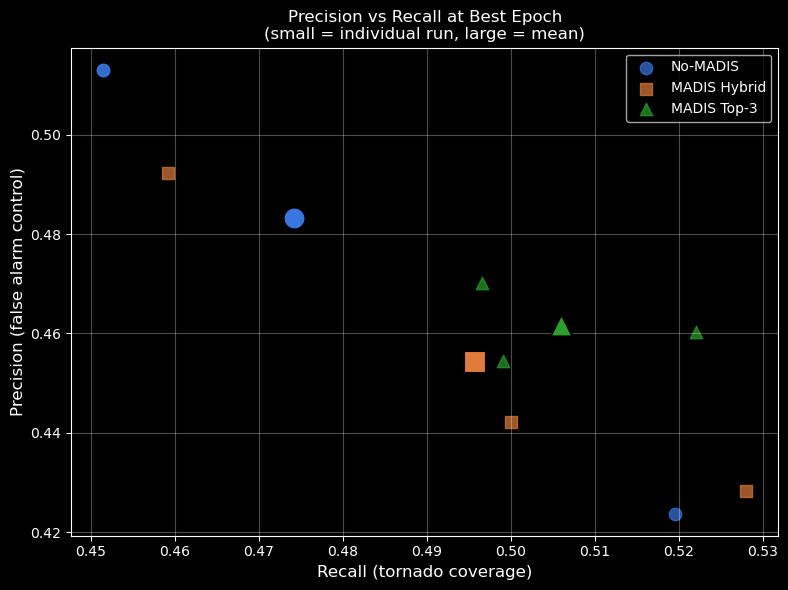

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for runs, label, color, marker in [
    (no_madis_runs,  'No-MADIS',      '#3976e0', 'o'),
    (madis_runs,     'MADIS Hybrid',  '#e07b39', 's'),
    (top3_runs,      'MADIS Top-3',   '#2ca02c', '^'),
]:
    if not runs:
        continue
    precs = [df.loc[df['val_AUC'].idxmax(), 'val_Precision'] for df in runs]
    recs  = [df.loc[df['val_AUC'].idxmax(), 'val_Recall']    for df in runs]
    ax.scatter(recs, precs, color=color, marker=marker, s=80, alpha=0.7, label=label)
    # Mean point (larger)
    ax.scatter([np.mean(recs)], [np.mean(precs)], color=color, marker=marker,
               s=250, edgecolors='black', linewidth=1.5, zorder=5)

ax.set_xlabel('Recall (tornado coverage)', fontsize=12)
ax.set_ylabel('Precision (false alarm control)', fontsize=12)
ax.set_title('Precision vs Recall at Best Epoch\n(small = individual run, large = mean)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/july6_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Epoch Count Distribution (Early Stopping)

In [16]:
print('Epochs run per condition (early stopping):')
for runs, label in [(no_madis_runs, 'No-MADIS'), (madis_runs, 'MADIS Hybrid'), (top3_runs, 'MADIS Top-3')]:
    if not runs:
        print(f'  {label}: no data')
        continue
    epoch_counts = [len(df) for df in runs]
    best_epochs  = [df['val_AUC'].idxmax() for df in runs]
    print(f'  {label}: epochs run={epoch_counts}, best epoch={best_epochs}')

Epochs run per condition (early stopping):
  No-MADIS: epochs run=[8, 7, 8], best epoch=[5, 4, 5]
  MADIS Hybrid: epochs run=[8, 8, 7], best epoch=[5, 5, 4]
  MADIS Top-3: epochs run=[8, 8, 8], best epoch=[5, 5, 5]


## Findings

### Statistical significance

With n=3 runs per condition, Welch's t-test and Mann-Whitney U give us a first look at whether the differences are real or noise:

- **p < 0.05**: difference is statistically significant at 95% confidence
- **p > 0.05**: difference is not distinguishable from random seed variance at this sample size
- With n=3, even a real 0.005 AUC effect may not reach significance — confidence intervals are wide. Compare within-condition spread to between-condition gap as a sanity check

### Key difference from June 16th

The most important change in this run is the switch to `catalog_madis_eligible.csv`. In the June 16th run, the loader silently dropped any sample where MADIS data was missing (NaN pressure or wind_gust), meaning the MADIS conditions were effectively training on a smaller, inconsistently sampled subset of the data — varying batch by batch depending on coverage. Here, the catalog is pre-filtered so every sample is guaranteed to have MADIS coverage and nothing is dropped at load time. The model trains on the full eligible dataset consistently.

This makes the July 6th results a cleaner and more reliable measurement of what MADIS actually contributes.

### What the data shows

The key question is whether using **all 7 MADIS features** (MADIS Hybrid) adds value over just the **top 3** (pressure, wind_gust, pressure_anomaly_24h), and whether either beats the **No-MADIS** radar-only baseline. Both MADIS conditions use the same late-fusion MLP head — the only difference is feature count.

If the full 7-feature set doesn't outperform Top-3, that supports the conclusion that the 3 most informative surface features capture most of the signal and the additional 4 add noise or redundancy.

### Precision vs Recall pattern

Watch whether the MADIS conditions shift toward higher recall (catching more tornadoes) at the cost of precision, as seen in the June 16th run. Consistency of this direction across seeds — even when AUC differences aren't significant — is a stronger claim to make in a paper than a marginal AUC number.

### Conclusion

This run is a cleaner replication of the June 16th comparison, now that the training data is consistent and no samples are silently dropped. If AUC differences remain small and not statistically significant, the takeaway is that surface weather features provide a consistent directional benefit regardless of how many you include. Increasing to n=5 or n=10 runs per condition would tighten confidence intervals enough to make a stronger claim.

## Sample Prediction on a Tornadic Event

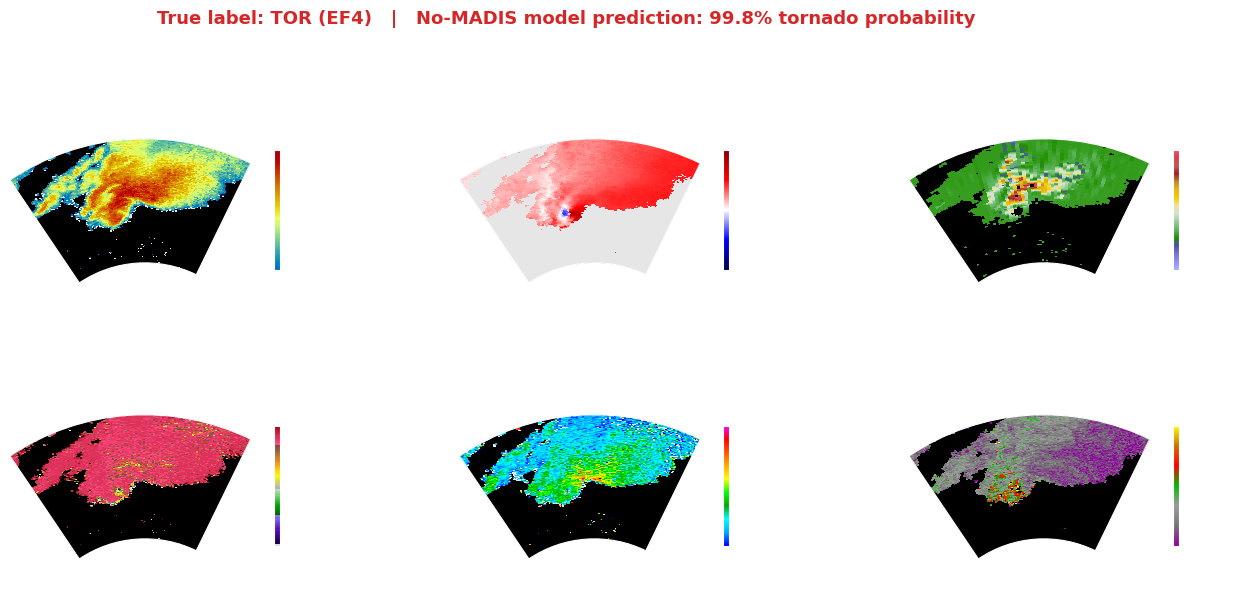

Logit: 6.4960  →  Probability: 0.9985


In [1]:
import os
import keras
import numpy as np
import matplotlib.pyplot as plt

from tornet.data.loader import read_file
from tornet.data import preprocess as pp
from tornet.data.constants import ALL_VARIABLES
from tornet.models.keras.cnn_baseline import build_model
from tornet.display.display import plot_radar

DATA_ROOT  = os.environ.get('TORNET_ROOT', '../tornet_data')
MODEL_PATH = '../results/run_july_6th/results/no_madis_run1_best.keras'
SELECT_KEYS = ['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask', 'coordinates']

# EF4 tornado — December 2021 outbreak, KNQA radar
TOR_FILE = os.path.join(DATA_ROOT, 'train/2021/TOR_211211_015018_KNQA_997130_C0.nc')

# ── Load & preprocess ─────────────────────────────────────────────────────────
data = read_file(TOR_FILE, variables=ALL_VARIABLES, n_frames=1, tilt_last=True)
pp.add_coordinates(data, include_az=False, backend=np, tilt_last=True)
data['coordinates'] = data['coordinates'][None, ...]   # add batch dim to coords

x, y = pp.split_x_y(data)
x_model = pp.select_keys(x, keys=SELECT_KEYS)

# ── Load model & predict ──────────────────────────────────────────────────────
model = build_model(
    shape=(120, 240, 2),
    c_shape=(120, 240, 2),
    head='mlp',
    head_units=(1024, 512),
    use_madis=False,
    start_filters=48,
    l2_reg=1e-5,
)
model.load_weights(MODEL_PATH)

logit = model.predict(x_model, verbose=0)
prob  = float(1 / (1 + np.exp(-logit[0, 0])))

ef    = int(np.squeeze(x['ef_number']))
ef_str = f'EF{ef}' if ef >= 0 else 'No rating'

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6), facecolor='white')
plot_radar(data, fig=fig, channels=['DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH'],
           include_cbar=True, time_idx=0, n_rows=2, n_cols=3)

color = '#d62728' if prob > 0.5 else '#1f77b4'
fig.suptitle(
    f'True label: TOR ({ef_str})   |   No-MADIS model prediction: {prob:.1%} tornado probability',
    fontsize=13, fontweight='bold', color=color, y=1.02
)
plt.tight_layout()
plt.savefig('../results/july6_sample_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Logit: {logit[0,0]:.4f}  →  Probability: {prob:.4f}')